In [10]:
import gdsfactory as gf
from ihp import PDK
from ihp.cells.capacitors import rfcmim
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

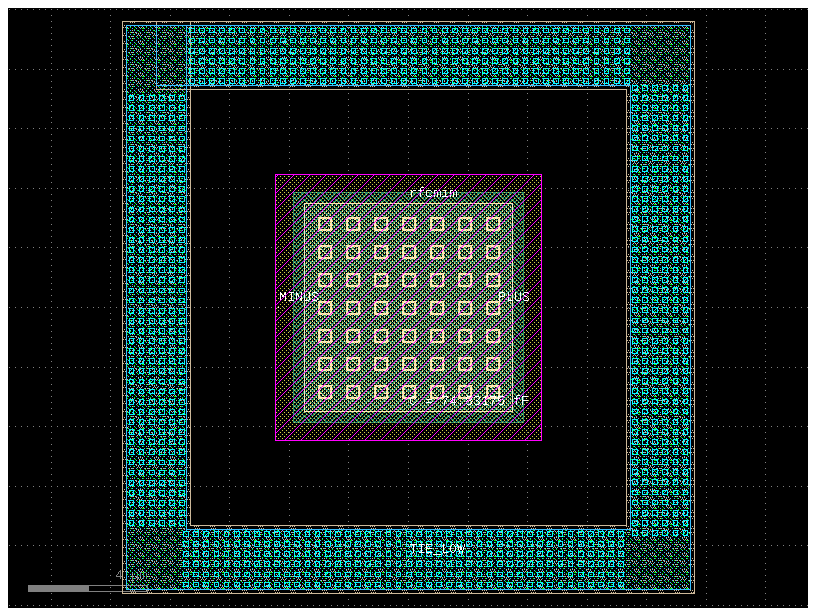

In [11]:
c = rfcmim(width=7.0, length=7.0)
c_plot = gf.Component()
for layer in c.layers:
    layer_number, datatype = layer
    if datatype != 0:
        continue
    layer_comp = c.extract(layers=[layer])
    c_plot.add_ref(layer_comp)

c_plot.draw_ports()
c_plot.plot()

In [12]:
cc = gf.Component()

layers_to_keep = [
    "Metal1pin",
    "Activdrawing",
    #"Contdrawing",
    "Metal1drawing",
    "pSDdrawing",
    "MIMdrawing",
    "Metal5drawing",
    "Metal5pin",
    "MemCapdrawing",
    "TopMetal1drawing",
    "TopMetal1pin",
    "Vmimdrawing",    
]

for layer in layers_to_keep:
    extracted = c.extract(layers=[layer])

    if not extracted.get_polygons():
        continue

    # Merge overlapping polygons on this layer
    merged = gf.boolean(
        A=extracted,
        B=extracted,
        operation="or",
        layer=layer,
    )

    cc.add_ref(merged)

cc.flatten()
cc.add_ports(c.ports)

In [13]:
cc.ports

["Port(self.name='MINUS', self.width=200, trans=r180 *1 -4.36,0, layer=Metal5pin (67/2), port_type=electrical)", "Port(self.name='PLUS', self.width=1000, trans=r0 *1 3,0, layer=TopMetal1pin (126/2), port_type=electrical)", "Port(self.name='TIE_LOW', self.width=2000, trans=r0 *1 0,-8.46, layer=Metal1pin (8/2), port_type=electrical)"]

In [14]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-rfcmim")
sim.set_geometry(cc)

sim.set_stack(yaml_path=yaml_file)

sim.add_port("PLUS",from_layer="metal5",to_layer="topmetal1",geometry="via",impedance=50.0)
sim.add_port("MINUS",from_layer="metal5",to_layer="topmetal1",geometry="via",impedance=50.0)

#sim.add_port("TIE_LOW",layer="metal1",length=2.0,geometry="inplane")
#Cannot add this port without getting error
#Error   : Invalid boundary mesh (overlapping facets) on surface 17 surface 771
sim.set_driven(fmin=1e9, fmax=20e9, num_points=21)

print(sim.validate_config())

Validation: PASSED


In [15]:
sim.mesh(preset="default")

Mesh Summary
Dimensions: 219.2 x 219.2 x 518.3 µm
Nodes:      1,538
Elements:   10,000
Tetrahedra: 4,829
Edge length: 0.01 - 168.57 µm
Quality:    0.399 (min: 0.000)
SICN:       0.427 (all valid)
----------------------------------------
Volumes (5):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - silicon [4]
  - airbox [5]
Surfaces (12):
  - active_xy [6]
  - active_z [7]
  - metal5_xy [8]
  - metal5_z [9]
  - metal1_xy [10]
  - metal1_z [11]
  - topmetal1_xy [12]
  - topmetal1_z [13]
  - vmim_xy [14]
  - P1 [15]
  - P2 [16]
  - Absorbing_boundary [17]
----------------------------------------
Mesh:   ../palace-sim-rfcmim/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 12:50:45.505 (  53.797s) [    7081E22B4080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 12:50:45.513 (  53.805s) [    7081E22B4080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
/home/delfina/projects/gsim/src/gsim/viz.py:77: UserWarning: Failed to use notebook backend: 

No module named 'trame.app'

Falling back to a static output.
  plotter.show()
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: fai

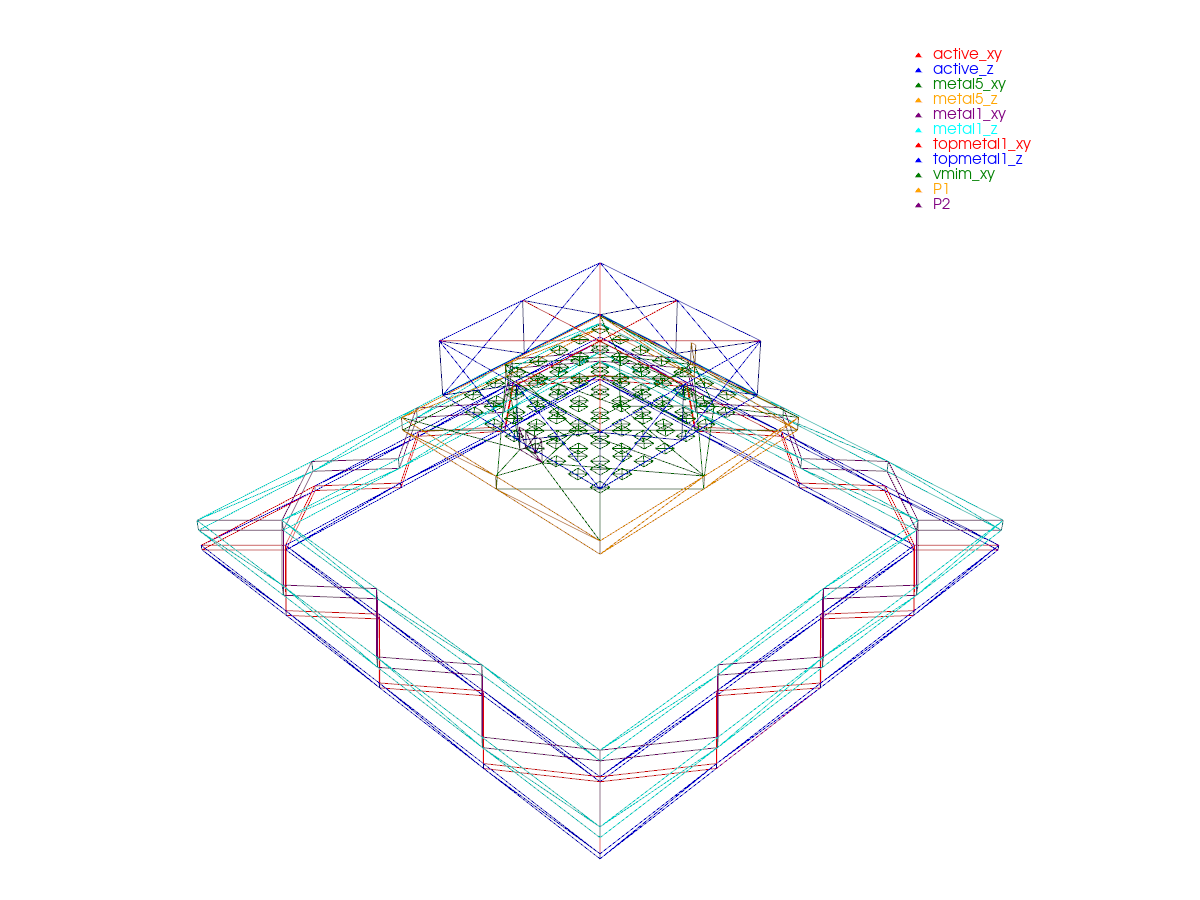

In [16]:
sim.plot_mesh(show_groups=["metal","active","vmim","P"],interactive=True)